### Agentic RAG is Easy!

For this project we will be locally setting up a LLM RAG Pipeline which will have -
1. Supervising Agent - This agent will keep a check on all the agents and instantiate them as
and when required.
2. Document Retrieval grading Agent - This agent will assess based on the user question if
the documents retrieved are accurate or not.
3. Hallucination grading Agent - This agent will assess the LLM response to check if the
generated answer is factually correct or not based on the documents used.
4. Answer grading Agent - This agent will assess the LLM response based on the question
asked if the answer meets the required criteria.
5. LangGraph Visualization - Capturing visual information of how all agents work in tandem.

All this controlled to have maximum retries of 3 through LangGraph Streamer

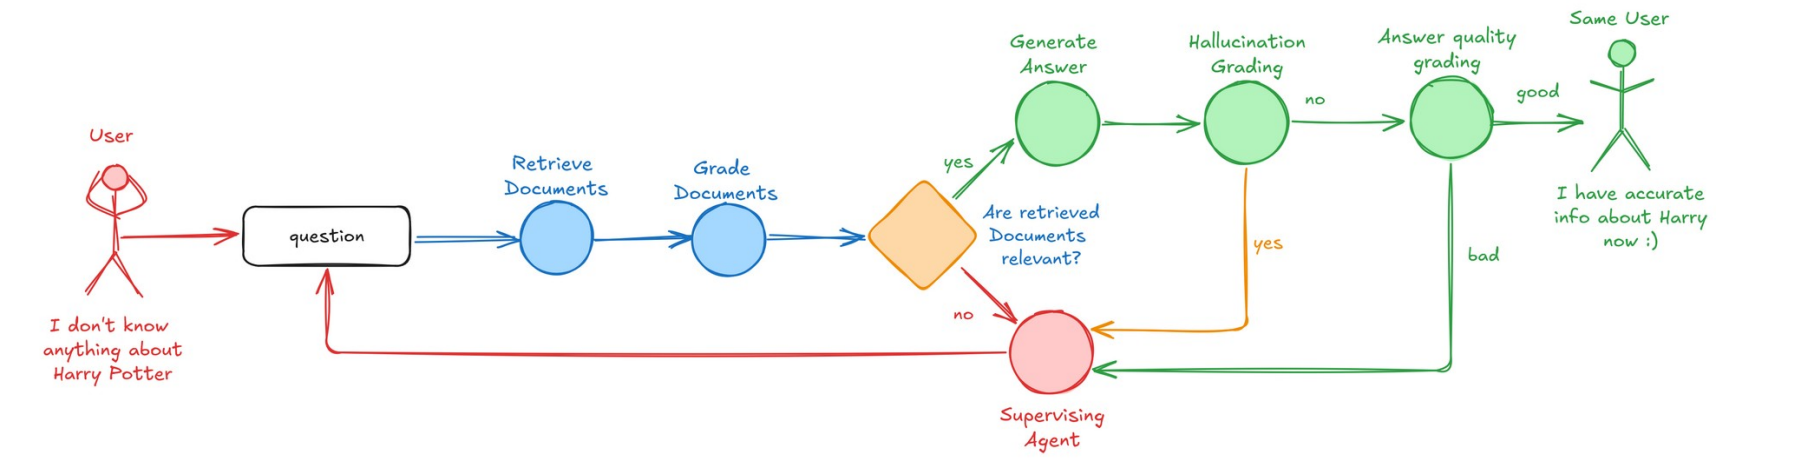

Installation and setup

In [ ]:
%%capture --no-stderr
%pip install --quiet -U langchain langchain_community tiktoken langchain-ollama scikit-learn langgraph tavily-python bs4 llama-cpp-python

### We roll on local resources!
Loading LLM and setting up parmeters


In [ ]:
from langchain.llms import LlamaCpp
# Path to your local GGUF model
local_model_path = f"LLM/Llama-3.2-3B-Instruct-f16.gguf"
# Initialize the LLM using LlamaCpp
llm = LlamaCpp(
 model_path=local_model_path,
 n_ctx=2048, # Adjust context size as needed
 temperature=0,
)


Loading the Embeddings Model

In [ ]:
from langchain.embeddings import LlamaCppEmbeddings
local_embeddings_model_path = f"Embeddings/nomic-embed-textv1.5.f16.gguf"
embeddings = LlamaCppEmbeddings(
 model_path=local_embeddings_model_path,
)


Creating a Vector Store for documents that we want to ingest

In [ ]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.document_loaders import DirectoryLoader, TextLoader, PyPDFLoader
from langchain_community.vectorstores import SKLearnVectorStore
from langchain_nomic.embeddings import NomicEmbeddings

# Load documents from local files (adjust the path and loader as needed)
# Use DirectoryLoader for a folder containing multiple files.
# Replace the loader if working with specific file types (e.g.,TextLoader for .txt, PDFLoader for PDFs).

docs_loader = DirectoryLoader(
 f"Documents", # Path to your local folder with documents
 glob="*.pdf", # Use "*.pdf" for PDFs or "*" for all files
 loader_cls=PyPDFLoader # Replace with PDFLoader for PDFs
)

# Load and read all documents
docs = docs_loader.load()

# Split documents
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
 chunk_size=1000, chunk_overlap=200
)
doc_splits = text_splitter.split_documents(docs)

# Add to vectorDB
vectorstore = SKLearnVectorStore.from_documents(
 documents=doc_splits,
 persist_path="Embeddings/Vectorstore",
 embedding=embeddings,
)

# Create retriever
retriever = vectorstore.as_retriever(k=3)

Retrieval Grading Agent

In [ ]:
import json
from langchain_core.messages import SystemMessage, HumanMessage

# Doc grader instructions
doc_grader_instructions = """You are a grader assessing relevance of a
retrieved document to a user question.
If the document contains keyword(s) or semantic meaning related to the
question, grade it as relevant."""

# Grader prompt
doc_grader_prompt = """
Given the following:
- RETRIEVED DOCUMENT: {document}
- QUESTION: {question}
Decide if we should proceed with generating an answer. Reply with
"GRADE" : "yes" or "no" with short explanation.
Strictly no additional info
"""
# Test
question = "Who is Harry Potter?"
docs = retriever.invoke(question)
doc_txt = docs[1].page_content
doc_grader_prompt_formatted = doc_grader_prompt.format(
 document=doc_txt, question=question
)
doc_grader_response = llm.invoke(
 [SystemMessage(content=doc_grader_instructions)]
 + [HumanMessage(content=doc_grader_prompt_formatted)]
)

print(doc_grader_response)

Answer Generation

In [ ]:
### Generate

# Prompt
rag_prompt = """You are an assistant for question-answering tasks.
Here is the context to use to answer the question:
{context}
Think carefully about the above context.
Now, review the user question:
{question}
Provide an answer to this questions using only the above context.
Use three sentences maximum and keep the answer concise.
Answer:"""

# Post-processing
def format_docs(docs):
 return "\n\n".join(doc.page_content for doc in docs)

# Test
docs = retriever.invoke(question)
docs_txt = format_docs(docs)
rag_prompt_formatted = rag_prompt.format(context=docs_txt,
question=question)
generation = llm.invoke([HumanMessage(content=rag_prompt_formatted)])
print(generation)


Hallucination Grading Agent

In [ ]:
### Hallucination Grader

# Hallucination grader instructions
hallucination_grader_instructions = """
You are a teacher grading a quiz.
You will be given FACTS and a STUDENT ANSWER.
Here is the grade criteria to follow:
(1) Ensure the STUDENT ANSWER is grounded in the FACTS.
(2) Ensure the STUDENT ANSWER does not contain "hallucinated"
information outside the scope of the FACTS.
Score:
A score of yes means that the student's answer meets all of the
criteria. This is the highest (best) score.
A score of no means that the student's answer does not meet all of the
criteria. This is the lowest possible score you can give.
Explain your reasoning in a step-by-step manner to ensure your
reasoning and conclusion are correct.
Avoid simply stating the correct answer at the outset."""

# Grader prompt
hallucination_grader_prompt = """
Given the following:
- FACTS: {documents}
- STUDENT ANSWER: {generation}
Decide if we should proceed with generating an answer. Reply with
"GRADE" : "yes" or "no".
"""
# Test using documents and generation from above
hallucination_grader_prompt_formatted = hallucination_grader_prompt.format(
 documents=docs_txt, generation=generation
)
hallucination_result = llm.invoke(
 [SystemMessage(content=hallucination_grader_instructions)]
 + [HumanMessage(content=hallucination_grader_prompt_formatted)]
)

print(hallucination_result)


Answer Grading Agent

In [ ]:
### Answer Grader

# Answer grader instructions
answer_grader_instructions = """
You are a teacher grading a quiz.
You will be given a QUESTION and a STUDENT ANSWER.
Here is the grade criteria to follow:
(1) The STUDENT ANSWER helps to answer the QUESTION
Score:
A score of yes means that the student's answer meets all of the
criteria. This is the highest (best) score.
The student can receive a score of yes if the answer contains extra
information that is not explicitly asked for in the question.
A score of no means that the student's answer does not meet all of the
criteria. This is the lowest possible score you can give.
Explain your reasoning in a step-by-step manner to ensure your
reasoning and conclusion are correct.
Avoid simply stating the correct answer at the outset."""

# Grader prompt
answer_grader_prompt = """
Given the following:
- QUESTION: {question}
- STUDENT ANSWER: {generation}
Decide if we should proceed with generating an answer. Reply with
"GRADE" : "yes" or "no"
"""
# Test
question = question
answer = generation

# Test using question and generation from above
answer_grader_prompt_formatted = answer_grader_prompt.format(
 question=question, generation=answer
)
answer_quality_result = llm.invoke(
 [SystemMessage(content=answer_grader_instructions)]
 + [HumanMessage(content=answer_grader_prompt_formatted)]
)

print(answer_quality_result)

Supervising Agent

In [ ]:
import json
from langchain_core.messages import SystemMessage, HumanMessage

# Supervisor instructions
supervisor_instructions = """
You are a teacher assessing your students.
You have three students
(1) DOCUMENT RETRIEVAL GRADER
(2) HALLUCINATION GRADER
(3) ANSWER QUALITY GRADER
You will be given FACTS and RESPONSES of your students .
Here is the grade criteria to follow -
A score of yes means that the student's answer meets all of the
criteria. This is the highest (best) score.
The student can receive a score of yes if the answer contains extra
information that is not explicitly asked for in the question.
A score of no means that the student's answer does not meet all of the
criteria. This is the lowest possible score you can give.
Explain your reasoning in a step-by-step manner to ensure your
reasoning and conclusion are correct.
Avoid simply stating the correct answer at the outset.
"""
# Supervisor prompt
supervisor_prompt = """
Given the following grader results:
- Document Grader: {doc_grader_response}
- Hallucination Grader: {hallucination_result}
- Answer Grader: {answer_quality_result}
Decide if we should proceed with generating an answer. Reply with
"GRADE" : "yes" or "no" with short explanation.
"""
# Test
question = "Who is Harry Potter?"
docs = retriever.invoke(question)
doc_txt = docs[1].page_content
supervisor_grader_instructions_formatted = supervisor_instructions.format(
 generation = generation
)
supervisor_grader_prompt_formatted = supervisor_prompt.format(
 doc_grader_response=doc_grader_response,
 hallucination_result=hallucination_result,
 answer_quality_result=answer_quality_result
)
supervisor_result = llm.invoke(
 [SystemMessage(content=supervisor_grader_instructions_formatted)]
 + [HumanMessage(content=supervisor_grader_prompt_formatted)]
)

print(supervisor_result)

Setting Up LangGraph!

In [ ]:
import operator
from typing_extensions import TypedDict
from typing import List, Annotated

class GraphState(TypedDict):
 """
 Graph state is a dictionary that contains information we want to
propagate to, and modify in, each graph node.
 """
 question: str # User question
 generation: str # LLM generation
 max_retries: int # Max number of retries for answer generation
 answers: int # Number of answers generated
 loop_step: Annotated[int, operator.add]
 documents: List[str] # List of retrieved documents

Each node in our graph is simply a function that:

(1) Take state as an input

(2) Modifies state

(3) Write the modified state to the state schema (dict)


In [ ]:
import re

### Helper Function
def extract_binary_score(response):
 """
 Extract the binary score (yes/no) from the LLM response.
 Args:
 response (str): The raw response string from the LLM.
 Returns:
 str: The grade ("yes" or "no") if found, else an empty string.
 """
 response = response.lower()
 match = re.search(r"{\s*grade\s*:\s*(yes|no)\s*}", response)
 return match.group(1) if match else ""

### Nodes
def retrieve(state):
 """
 Retrieve documents from vectorstore
 Args:
 state (dict): The current graph state
 Returns:
 state (dict): New key added to state, documents, that contains
retrieved documents
 """
 print("---RETRIEVE---")
 question = state["question"]
 # Write retrieved documents to documents key in state
 documents = retriever.invoke(question)
 return {"documents": documents}

def generate(state):
 """
 Generate answer using RAG on retrieved documents
 Args:
 state (dict): The current graph state
 Returns:
 state (dict): New key added to state, generation, that contains LLM generation
 """
 print("---GENERATE---")
 question = state["question"]
 documents = state["documents"]
 loop_step = state.get("loop_step", 0)
 # RAG generation
 docs_txt = format_docs(documents)
 rag_prompt_formatted = rag_prompt.format(context=docs_txt,
question=question)
 generation = llm.invoke([HumanMessage(content=rag_prompt_formatted)])
 return {"generation": generation, "loop_step": loop_step + 1}

def grade_documents(state):
 """
Determines whether the retrieved documents are relevant to the question
Args:
state (dict): The current graph state
Returns:
state (dict): Filtered out irrelevant documents
"""
 print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
 question = state["question"]
 documents = state["documents"]
 # Score each doc
 filtered_docs = []
 for d in documents:
   doc_grader_prompt_formatted = doc_grader_prompt.format(
    document=d.page_content, question=question
    )
   result = llm.invoke(
    [SystemMessage(content=doc_grader_instructions)] + 
    [HumanMessage(content=doc_grader_prompt_formatted)]
    )
   grade = extract_binary_score(result)
   if grade == "yes":
     print("---GRADE: DOCUMENT RELEVANT---")
     filtered_docs.append(d)
   else:
     print("---GRADE: DOCUMENT NOT RELEVANT---")
     # Document is not added to filtered_docs
     continue
 return {"documents": filtered_docs}


def grade_generation_v_documents_and_question(state):
 """
 Determines whether the generation is grounded in the document and answers question
 Args:
 state (dict): The current graph state
 Returns:
 str: Decision for next node to call
 """
 print("---CHECK HALLUCINATIONS---")
 question = state["question"]
 documents = state["documents"]
 generation = state["generation"]
 max_retries = state.get("max_retries", 3) # Default to 3 if not provided
 hallucination_grader_prompt_formatted = hallucination_grader_prompt.format(
  documents=format_docs(documents), generation=generation.content)
 hallucination_result = llm.invoke(
  [SystemMessage(content=hallucination_grader_instructions)] + [HumanMessage(content=hallucination_grader_prompt_formatted)]
  )
 hallucinnation_score = extract_binary_score(hallucination_result)
 # Check hallucination
 if hallucination_score == "yes":
  print("---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---")
  # Check question-answering
  print("---GRADE GENERATION vs QUESTION---")
  answer_grader_prompt_formatted = answer_grader_prompt.format(
   question=question, generation=generation.content
   )
  answer_result = llm.invoke(
   [SystemMessage(content=answer_grader_instructions)]
   + [HumanMessage(content=answer_grader_prompt_formatted)]
   )
  answer_score = extract_binary_score(answer_result)
  if answer_score == "yes":
   print("---DECISION: GENERATION ADDRESSES QUESTION---")
   return "useful"
  elif state["loop_step"] <= max_retries:
   print("---DECISION: GENERATION DOES NOT ADDRESS QUESTION---")
   return "not useful"
  else:
   print("---DECISION: MAX RETRIES REACHED---")
   return "max retries"
 elif state["loop_step"] <= max_retries:
  print("---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY---")
  return "not supported"
 else:
  print("---DECISION: MAX RETRIES REACHED---")
  return "max retries"
 
def supervising_agent(state):
 """
 Aggregates the results from various graders to make a final binary
decision.
 Args:
 state (dict): The current graph state
 Returns:
 str: Binary disposition ('yes' or 'no') based on aggregated
grader outputs.
 """
 print("---SUPERVISING AGENT---")
 doc_grader_result = state.get("doc_grader_result", "no")
 hallucination_grader_result = state.get("hallucination_grader_result", "no")
 answer_grader_result = state.get("answer_grader_result", "no")
 # Create a supervising prompt based on grader results
 supervising_prompt = supervisor_grader_prompt_formatted.format(
 doc_grader=doc_grader_result,
 hallucination_grader=hallucination_grader_result,
 answer_grader=answer_grader_result,
 )
 # Get supervising agent disposition
 result = llm.invoke(

[SystemMessage(content=supervisor_grader_instructions_formatted)]
 + [HumanMessage(content=supervising_prompt)]
 )
 disposition = extract_binary_score(result)
 return {"supervising_disposition": disposition}
### Simplified Edges
def decide_to_generate(state):
 """
 Determines whether to generate an answer or retry
 Args:
 state (dict): The current graph state
 Returns:
 str: Decision for next node to call
 """
 print("---ASSESS GRADED DOCUMENTS---")
 filtered_documents = state["documents"]
 
 if filtered_documents:
  # We have relevant documents, so generate answer 
  print("---DECISION: GENERATE---")
  return "generate"
 else:
  # No relevant documents available; retry logic may be added here if needed
  print("---DECISION: NO RELEVANT DOCUMENTS---")
  return "halt"

from langgraph.graph import StateGraph
from IPython.display import Image, display
workflow = StateGraph(GraphState)
# Define the nodes
workflow.add_node("retrieve", retrieve) # Retrieve documents
workflow.add_node("grade_documents", grade_documents) # Grade
documents
workflow.add_node("supervising_agent", supervising_agent) # Supervising agent
workflow.add_node("generate", generate) # Generate answer
# Build graph
workflow.set_entry_point("retrieve") # Entry point is directly
"retrieve"
workflow.add_edge("retrieve", "grade_documents") # Retrieve flows to grading documents
workflow.add_edge("grade_documents", "supervising_agent") # Grading flows to supervising agent
workflow.add_conditional_edges(
 "supervising_agent",
 lambda state: state.get("supervising_disposition", "no"),
 {
 "yes": "generate", # Proceed to generate if disposition is
"yes"
 "no": END, # Terminate workflow if disposition is "no"
 },
)
workflow.add_conditional_edges(
 "generate",
 grade_generation_v_documents_and_question,
 {
 "not supported": "generate", # Retry generation if hallucination or grounding fails
 "useful": END, # End if generation is useful
 "not useful": END, # End if generation is not useful after retries
 "max retries": END, # Terminate if retries exceed the maximum
 },
)
# Compile
graph = workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
inputs = {"question": "Who is Harry Potter?", "max_retries": 3}
for event in graph.stream(inputs, stream_mode="values"):
 print(event)